In [17]:
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

import joblib

In [18]:
uploaded = files.upload()

Saving train2.csv to train2 (1).csv


In [19]:
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Using file:", file_name)
print("Shape:", df.shape)
df.head()

Using file: train2 (1).csv
Shape: (54808, 13)


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [20]:
def clean_col(col):
    col = col.strip().lower()
    col = col.replace(" ", "_")
    col = col.replace(">", "gt")
    col = col.replace("<", "lt")
    col = col.replace("%", "pct")
    col = col.replace("?", "")
    col = col.replace("/", "_")
    return col

df.columns = [clean_col(c) for c in df.columns]
df.columns.tolist()

['employee_id',
 'department',
 'region',
 'education',
 'gender',
 'recruitment_channel',
 'no_of_trainings',
 'age',
 'previous_year_rating',
 'length_of_service',
 'awards_won',
 'avg_training_score',
 'is_promoted']

In [21]:
print(df.info())
print("\nMissing values:\n")
print(df.isnull().sum().sort_values(ascending=False))

print("\nTarget distribution:\n")
print(df["is_promoted"].value_counts())
print("\nTarget ratio:\n")
print(df["is_promoted"].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won            54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.4+ MB
None

Missing values:

previous_year_rating    4124
education   

In [22]:
X = df.drop(columns=["is_promoted", "employee_id"], errors="ignore")
y = df["is_promoted"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (54808, 11)
y shape: (54808,)


In [23]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

Categorical columns: ['department', 'region', 'education', 'gender', 'recruitment_channel']
Numerical columns: ['no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'awards_won', 'avg_training_score']


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (43846, 11)
X_test: (10962, 11)


In [25]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

In [26]:
log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [27]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    scores = {
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs)
    }

    print(f"\n===== {name} =====")
    print(classification_report(y_test, preds))

    ConfusionMatrixDisplay.from_predictions(y_test, preds)
    plt.show()

    return scores

In [28]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
}).sort_values(by="importance", ascending=False)

importance_df.head(10)

,feature,importance
10,avg_training_score,0.298942
0,department,0.208459
7,previous_year_rating,0.057747
9,awards_won,0.027540
5,no_of_trainings,-0.000179
3,gender,-0.003222
1,region,-0.004475
2,education,-0.004522
4,recruitment_channel,-0.007948
6,age,-0.008077


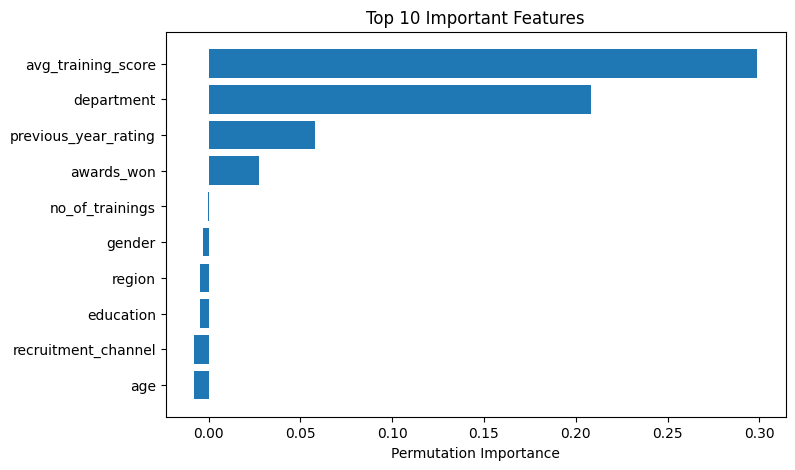

In [29]:
top_features = importance_df.head(10).sort_values(by="importance")

plt.figure(figsize=(8, 5))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 10 Important Features")
plt.xlabel("Permutation Importance")
plt.show()


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.96      0.77      0.86     10028
           1       0.21      0.67      0.33       934

    accuracy                           0.76     10962
   macro avg       0.59      0.72      0.59     10962
weighted avg       0.90      0.76      0.81     10962



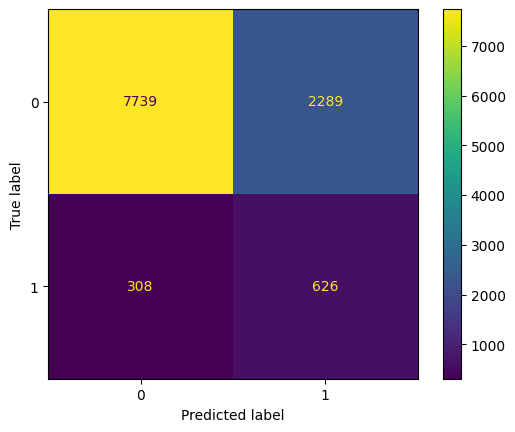


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.94      0.97      0.96     10028
           1       0.56      0.39      0.46       934

    accuracy                           0.92     10962
   macro avg       0.75      0.68      0.71     10962
weighted avg       0.91      0.92      0.92     10962



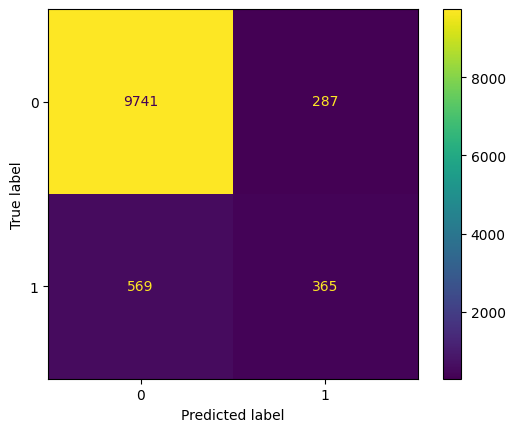

,model,accuracy,precision,recall,f1,roc_auc
1,Random Forest,0.921912,0.559816,0.390792,0.460277,0.801566
0,Logistic Regression,0.763091,0.214751,0.670236,0.325279,0.797671


In [30]:
results = []

results.append(evaluate_model(
    "Logistic Regression",
    log_reg_model,
    X_train, X_test, y_train, y_test
))

results.append(evaluate_model(
    "Random Forest",
    rf_model,
    X_train, X_test, y_train, y_test
))

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)
results_df

In [31]:
joblib.dump(best_model, "best_employee_promotion_model.pkl")
print("Model saved successfully.")

Model saved successfully.


In [32]:
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

probs = best_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]

print("Best threshold:", best_threshold)
print("Best F1 from threshold tuning:", f1_scores.max())

Best threshold: 0.4780542408929401
Best F1 from threshold tuning: 0.4645858338410841


Tuned Precision: 0.5286885245901639
Tuned Recall: 0.4143468950749465
Tuned F1: 0.4645858343337335


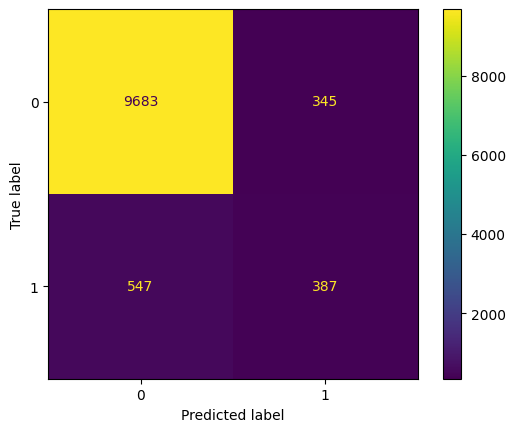

In [33]:
tuned_preds = (probs >= best_threshold).astype(int)

print("Tuned Precision:", precision_score(y_test, tuned_preds))
print("Tuned Recall:", recall_score(y_test, tuned_preds))
print("Tuned F1:", f1_score(y_test, tuned_preds))

ConfusionMatrixDisplay.from_predictions(y_test, tuned_preds)
plt.show()

In [34]:
summary_df = importance_df.head(5).copy()
summary_df

,feature,importance
10,avg_training_score,0.298942
0,department,0.208459
7,previous_year_rating,0.057747
9,awards_won,0.027540
5,no_of_trainings,-0.000179


In [36]:
print("Best baseline model: Random Forest")
print("Default-threshold F1:", 0.460277)
print("Tuned-threshold F1:", 0.464586)
print("Threshold tuning slightly improved F1 and recall, while precision decreased slightly.")
print("Top predictive features were avg_training_score, department, previous_year_rating, and awards_won.")

Best baseline model: Random Forest
Default-threshold F1: 0.460277
Tuned-threshold F1: 0.464586
Threshold tuning slightly improved F1 and recall, while precision decreased slightly.
Top predictive features were avg_training_score, department, previous_year_rating, and awards_won.


## Key Findings

- Random Forest performed better than Logistic Regression on the baseline comparison.
- Threshold tuning slightly improved F1-score and recall.
- The most important predictors of promotion were:
  - avg_training_score
  - department
  - previous_year_rating
  - awards_won
- no_of_trainings had negligible importance in the final model.